In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
print("Device:", device)
print("PyTorch:", torch.__version__)

Device: cuda:0
PyTorch: 2.10.0+cu128


In [3]:
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(28, padding=4),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])

NAMES = ["T-shirt/Top","Trouser","Pullover","Dress","Coat",
         "Sandal","Shirt","Sneaker","Bag","Ankle Boot"]

In [4]:
# ---- Split: 70% train / 15% val / 15% test (from the 60k training images) ----
n_total = 60000
n_train = int(0.70 * n_total)      # 42000
n_val   = int(0.15 * n_total)      # 9000
n_test  = n_total - n_train - n_val  # 9000

# Deterministic, reproducible split by explicit index permutation.
# Each Subset wraps a *separate* FashionMNIST instance with the correct transform,
# so train gets augmentation and val/test do not — with no reliance on
# internal dataset ordering.
g = torch.Generator().manual_seed(42)
perm = torch.randperm(n_total, generator=g).tolist()

train_idx = perm[:n_train]
val_idx   = perm[n_train:n_train + n_val]
test_idx  = perm[n_train + n_val:]

train_set = Subset(
    torchvision.datasets.FashionMNIST("./data", train=True, download=True, transform=train_tf),
    train_idx)
val_set = Subset(
    torchvision.datasets.FashionMNIST("./data", train=True, transform=eval_tf),
    val_idx)
test_set = Subset(
    torchvision.datasets.FashionMNIST("./data", train=True, transform=eval_tf),
    test_idx)

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=512, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=512, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train: {len(train_set)}  Val: {len(val_set)}  Test: {len(test_set)}")

100%|██████████| 26.4M/26.4M [00:00<00:00, 118MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.89MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 59.1MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.2MB/s]


Train: 42000  Val: 9000  Test: 9000


In [6]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden, bias=False),
            nn.SiLU(inplace=True),
            nn.Linear(hidden, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.act   = nn.SiLU(inplace=True)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.se    = SEBlock(out_ch)

        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.act(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.se(out)

        out = out + identity
        out = self.act(out)
        return out


class FashionResNet(nn.Module):
    def __init__(self, num_classes=10, dropout=0.3):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(1, 64, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True)
        )

        self.layer1 = nn.Sequential(
            ResBlock(64, 64, stride=1, dropout=0.05),
            ResBlock(64, 64, stride=1, dropout=0.05)
        )
        self.layer2 = nn.Sequential(
            ResBlock(64, 128, stride=2, dropout=0.10),
            ResBlock(128, 128, stride=1, dropout=0.10)
        )
        self.layer3 = nn.Sequential(
            ResBlock(128, 256, stride=2, dropout=0.15),
            ResBlock(256, 256, stride=1, dropout=0.15)
        )

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


model = FashionResNet(num_classes=10, dropout=0.3).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nTotal Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

FashionResNet(
  (stem): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (layer1): Sequential(
    (0): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
      (dropout): Dropout2d(p=0.05, inplace=False)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (se): SEBlock(
        (pool): AdaptiveAvgPool2d(output_size=1)
        (fc): Sequential(
          (0): Linear(in_features=64, out_features=8, bias=False)
          (1): SiLU(inplace=True)
          (2): Linear(in_features=8, out_features=64, bias=Fals

In [7]:
EPOCHS        = 200
PATIENCE      = 20      # stop if validation accuracy doesn't improve for 20 epochs
LABEL_SMOOTH  = 0.1

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler    = torch.cuda.amp.GradScaler()          # mixed precision (~2x faster on GPU)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc, best_epoch, wait = 0.0, -1, 0

for epoch in range(EPOCHS):
    # ---------------- TRAIN ----------------
    model.train()
    running, correct, n = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            out  = model(images)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        running  += loss.item() * len(labels)
        correct  += (out.argmax(1) == labels).sum().item()
        n        += len(labels)
    scheduler.step()
    history["train_loss"].append(running / n)
    history["train_acc"].append(correct / n)

    # ---------------- VALIDATION ----------------
    model.eval()
    vloss, vcorrect, vn = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            with torch.cuda.amp.autocast():
                out = model(images)
                vloss += criterion(out, labels).item() * len(labels)
            vcorrect += (out.argmax(1) == labels).sum().item()
            vn       += len(labels)
    val_loss, val_acc = vloss / vn, vcorrect / vn
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # ---- early stopping + best checkpoint ----
    improved = val_acc > best_val_acc
    if improved:
        best_val_acc, best_epoch, wait = val_acc, epoch + 1, 0
        torch.save(model.state_dict(), "best_model.pt")   # save BEST weights only
    else:
        wait += 1

    print(f"Epoch {epoch+1:3d}/{EPOCHS}  "
          f"train_loss={history['train_loss'][-1]:.4f}  train_acc={history['train_acc'][-1]*100:.2f}%  "
          f"val_loss={val_loss:.4f}  val_acc={val_acc*100:.2f}%  "
          f"lr={scheduler.get_last_lr()[0]:.2e}" + ("  *best*" if improved else ""))

    if wait >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1} (best epoch: {best_epoch}, "
              f"best val_acc={best_val_acc*100:.2f}%)")
        break

/tmp/ipykernel_58/2679347571.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()          # mixed precision (~2x faster on GPU)
/tmp/ipykernel_58/2679347571.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_58/2679347571.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch   1/200  train_loss=1.0989  train_acc=72.96%  val_loss=0.8893  val_acc=81.56%  lr=1.00e-03  *best*
Epoch   2/200  train_loss=0.9093  train_acc=81.50%  val_loss=0.8058  val_acc=86.52%  lr=1.00e-03  *best*
Epoch   3/200  train_loss=0.8392  train_acc=85.16%  val_loss=0.8202  val_acc=85.90%  lr=9.99e-04
Epoch   4/200  train_loss=0.8094  train_acc=86.21%  val_loss=0.7853  val_acc=86.99%  lr=9.99e-04  *best*
Epoch   5/200  train_loss=0.7839  train_acc=87.38%  val_loss=0.7405  val_acc=89.00%  lr=9.98e-04  *best*
Epoch   6/200  train_loss=0.7643  train_acc=88.26%  val_loss=0.6968  val_acc=91.13%  lr=9.98e-04  *best*
Epoch   7/200  train_loss=0.7496  train_acc=89.00%  val_loss=0.6941  val_acc=91.29%  lr=9.97e-04  *best*
Epoch   8/200  train_loss=0.7388  train_acc=89.40%  val_loss=0.6898  val_acc=91.52%  lr=9.96e-04  *best*
Epoch   9/200  train_loss=0.7283  train_acc=89.94%  val_loss=0.6913  val_acc=91.28%  lr=9.95e-04
Epoch  10/200  train_loss=0.7165  train_acc=90.46%  val_loss=0.6805  va

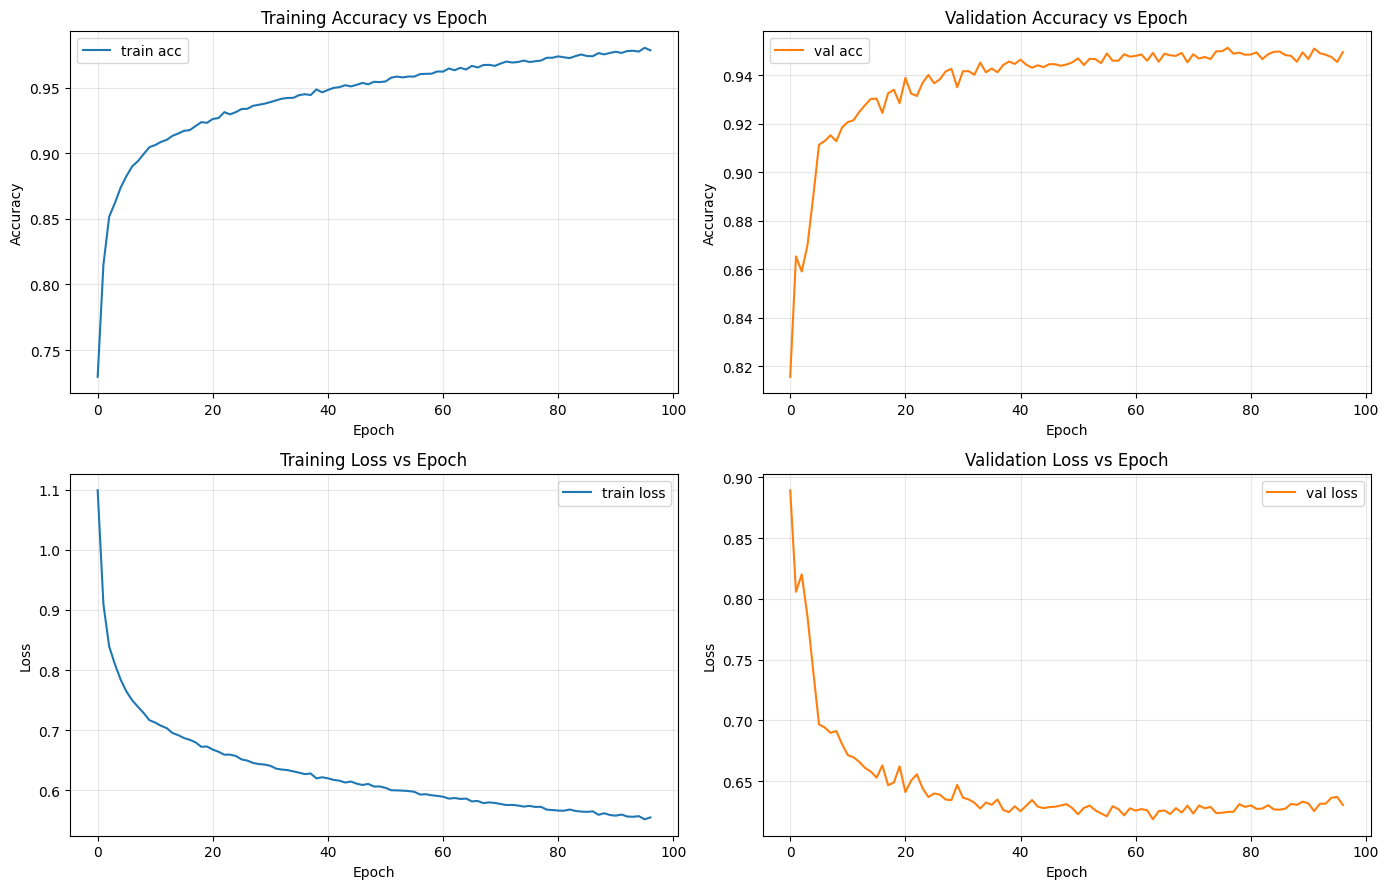

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].plot(history["train_acc"], label="train acc")
axes[0,0].set_title("Training Accuracy vs Epoch"); axes[0,0].set_xlabel("Epoch"); axes[0,0].set_ylabel("Accuracy")
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(history["val_acc"], color="tab:orange", label="val acc")
axes[0,1].set_title("Validation Accuracy vs Epoch"); axes[0,1].set_xlabel("Epoch"); axes[0,1].set_ylabel("Accuracy")
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(history["train_loss"], label="train loss")
axes[1,0].set_title("Training Loss vs Epoch"); axes[1,0].set_xlabel("Epoch"); axes[1,0].set_ylabel("Loss")
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(history["val_loss"], color="tab:orange", label="val loss")
axes[1,1].set_title("Validation Loss vs Epoch"); axes[1,1].set_xlabel("Epoch"); axes[1,1].set_ylabel("Loss")
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
model.load_state_dict(
    torch.load("best_model.pt", map_location=device, weights_only=True)
)
model.eval()

all_pred, all_label = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        all_pred.append(model(images).argmax(1).cpu())
        all_label.append(labels)

preds  = torch.cat(all_pred).numpy()
labels = torch.cat(all_label).numpy()

print("=" * 55)
print(f"TEST ACCURACY: {(preds == labels).mean() * 100:.2f}%")
print("=" * 55)
print(classification_report(labels, preds, target_names=NAMES))

TEST ACCURACY: 94.66%
              precision    recall  f1-score   support

 T-shirt/Top       0.89      0.90      0.90       970
     Trouser       1.00      0.99      1.00       927
    Pullover       0.90      0.92      0.91       890
       Dress       0.94      0.95      0.95       858
        Coat       0.95      0.91      0.93       869
      Sandal       0.99      0.99      0.99       892
       Shirt       0.85      0.85      0.85       942
     Sneaker       0.97      0.98      0.98       832
         Bag       1.00      0.99      0.99       885
  Ankle Boot       0.98      0.97      0.98       935

    accuracy                           0.95      9000
   macro avg       0.95      0.95      0.95      9000
weighted avg       0.95      0.95      0.95      9000



In [11]:
cm = confusion_matrix(labels, preds)
TP = np.diag(cm).astype(float)
FP = cm.sum(axis=0) - TP
FN = cm.sum(axis=1) - TP

dice = 2 * TP / (2 * TP + FP + FN)
iou  = TP / (TP + FP + FN)

print("Per-class Dice:")
for name, d in zip(NAMES, dice):
    print(f"  {name:12s}  {d:.4f}")
print(f"\nMean Dice (mDice): {dice.mean():.4f}")
print(f"Mean IoU  (mIoU):  {iou.mean():.4f}")

Per-class Dice:
  T-shirt/Top   0.8990
  Trouser       0.9957
  Pullover      0.9113
  Dress         0.9466
  Coat          0.9315
  Sandal        0.9905
  Shirt         0.8520
  Sneaker       0.9762
  Bag           0.9932
  Ankle Boot    0.9779

Mean Dice (mDice): 0.9474
Mean IoU  (mIoU):  0.9035


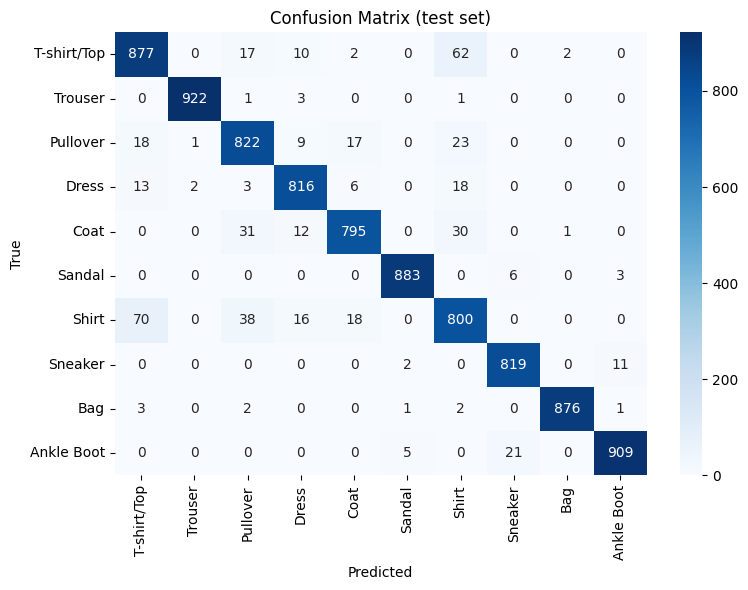

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=NAMES, yticklabels=NAMES)
plt.title("Confusion Matrix (test set)")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()